Pipistrellus sampling rate: 384000
Myotis sampling rate: 40000


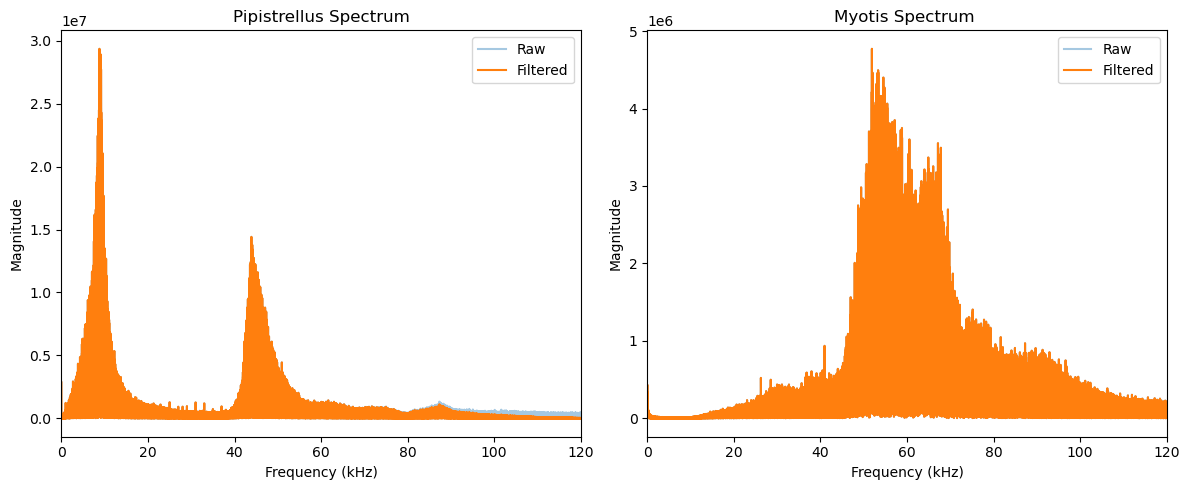

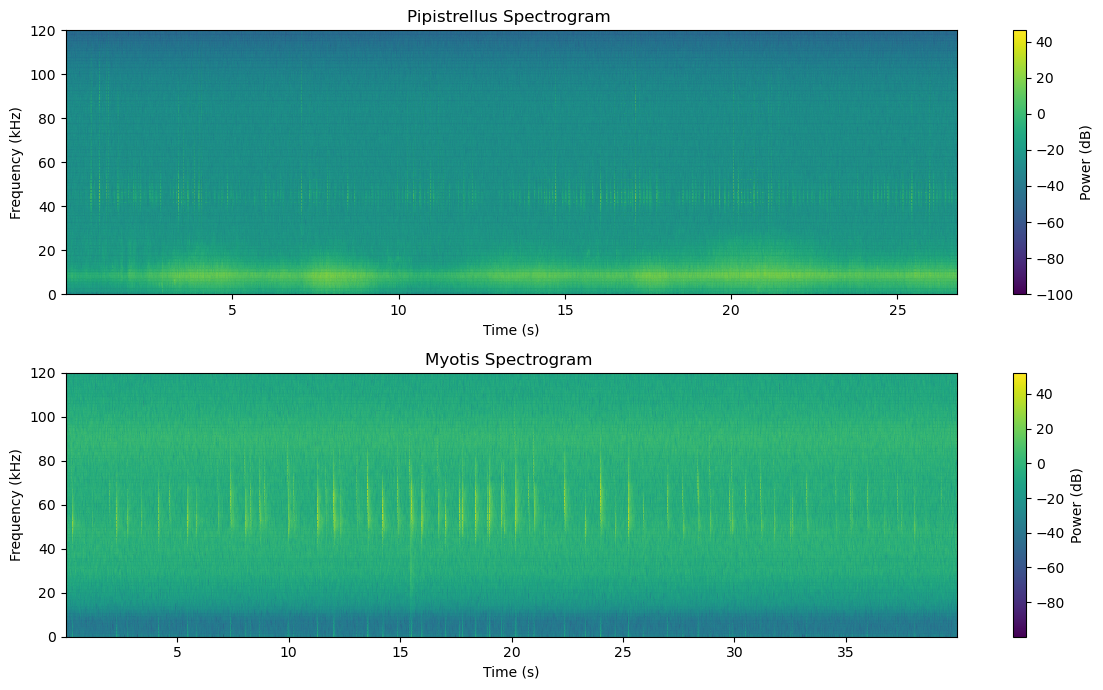

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, spectrogram
from scipy.fft import fft
import warnings
warnings.filterwarnings("ignore")

# Files
pip_file = "Pipistrellus/A005200_HECGNLLRCI.WAV"
myo_file = "Myotis/A005845_AXIWDWNQRZ.WAV"

division_factor = 10   # assumed for Myotis detector

sr_pip, pip_audio = wavfile.read(pip_file)
sr_myo, myo_audio = wavfile.read(myo_file)



print("Pipistrellus sampling rate:", sr_pip)
print("Myotis sampling rate:", sr_myo)

# Low Pass Filter

def lowpass_filter(signal, fs, cutoff, order=4):

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)

    return filtered


pip_filtered = lowpass_filter(pip_audio, sr_pip, cutoff=100000)
myo_filtered = lowpass_filter(myo_audio, sr_myo, cutoff=15000)


def compute_fft(signal, sr):

    N = len(signal)

    spectrum = np.abs(fft(signal))[:N//2]
    freqs = np.linspace(0, sr/2, N//2)

    return freqs, spectrum

# compute spectra
pip_freq_raw, pip_spec_raw = compute_fft(pip_audio, sr_pip)
pip_freq_filt, pip_spec_filt = compute_fft(pip_filtered, sr_pip)

myo_freq_raw, myo_spec_raw = compute_fft(myo_audio, sr_myo)
myo_freq_filt, myo_spec_filt = compute_fft(myo_filtered, sr_myo)

# apply division factor correction to Myotis
myo_freq_raw_corrected = myo_freq_raw * division_factor
myo_freq_filt_corrected = myo_freq_filt * division_factor

# Plots

plt.figure(figsize=(12,5))

# Pipistrellus
plt.subplot(1,2,1)

plt.plot(pip_freq_raw/1000, pip_spec_raw, alpha=0.4, label="Raw")
plt.plot(pip_freq_filt/1000, pip_spec_filt, label="Filtered")

plt.title("Pipistrellus Spectrum")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0,120)
plt.legend()

# Myotis
plt.subplot(1,2,2)

plt.plot(myo_freq_raw_corrected/1000, myo_spec_raw, alpha=0.4, label="Raw")
plt.plot(myo_freq_filt_corrected/1000, myo_spec_filt, label="Filtered")

plt.title("Myotis Spectrum ")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0,120)
plt.legend()

plt.tight_layout()
plt.show()

# Spectrogram Graphs

plt.figure(figsize=(12,7))

# Pipistrellus spectrogram
plt.subplot(2,1,1)

f, t, Sxx = spectrogram(pip_filtered, sr_pip)

plt.pcolormesh(t, f/1000,
               10*np.log10(Sxx + 1e-10),
               shading='gouraud')

plt.title("Pipistrellus Spectrogram ")
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.ylim(0,120)
plt.colorbar(label="Power (dB)")

# Myotis spectrogram
plt.subplot(2,1,2)

f, t, Sxx = spectrogram(myo_filtered, sr_myo)

plt.pcolormesh(t, (f*division_factor)/1000,
               10*np.log10(Sxx + 1e-10),
               shading='gouraud')

plt.title("Myotis Spectrogram ")
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.ylim(0,120)
plt.colorbar(label="Power (dB)")

plt.tight_layout()
plt.show()

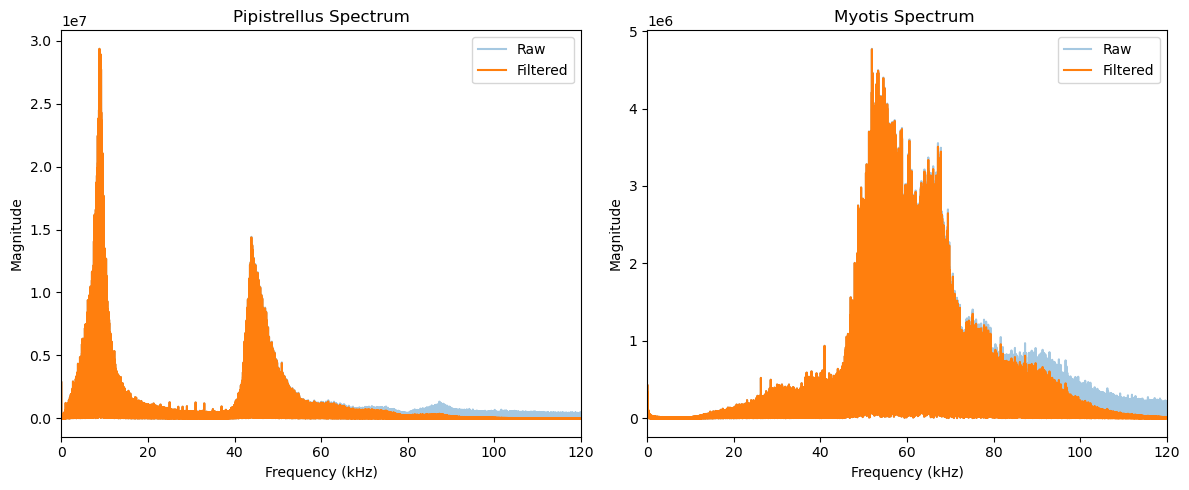

In [15]:
def lowpass_filter(signal, fs, cutoff, order=4):

    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')
    filtered = filtfilt(b, a, signal)

    return filtered

pip_filtered = lowpass_filter(pip_audio, sr_pip, cutoff=80000)
myo_filtered = lowpass_filter(myo_audio, sr_myo, cutoff=10000)


def compute_fft(signal, sr):

    N = len(signal)

    spectrum = np.abs(fft(signal))[:N//2]
    freqs = np.linspace(0, sr/2, N//2)

    return freqs, spectrum

pip_freq_raw, pip_spec_raw = compute_fft(pip_audio, sr_pip)
pip_freq_filt, pip_spec_filt = compute_fft(pip_filtered, sr_pip)

myo_freq_raw, myo_spec_raw = compute_fft(myo_audio, sr_myo)
myo_freq_filt, myo_spec_filt = compute_fft(myo_filtered, sr_myo)

myo_freq_raw_corrected = myo_freq_raw * division_factor
myo_freq_filt_corrected = myo_freq_filt * division_factor


# Plots
plt.figure(figsize=(12,5))

# Pipistrellus
plt.subplot(1,2,1)

plt.plot(pip_freq_raw/1000, pip_spec_raw, alpha=0.4, label="Raw")
plt.plot(pip_freq_filt/1000, pip_spec_filt, label="Filtered")

plt.title("Pipistrellus Spectrum")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0,120)
plt.legend()

# Myotis
plt.subplot(1,2,2)

plt.plot(myo_freq_raw_corrected/1000, myo_spec_raw, alpha=0.4, label="Raw")
plt.plot(myo_freq_filt_corrected/1000, myo_spec_filt, label="Filtered")

plt.title("Myotis Spectrum ")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Magnitude")
plt.xlim(0,120)
plt.legend()

plt.tight_layout()
plt.show()

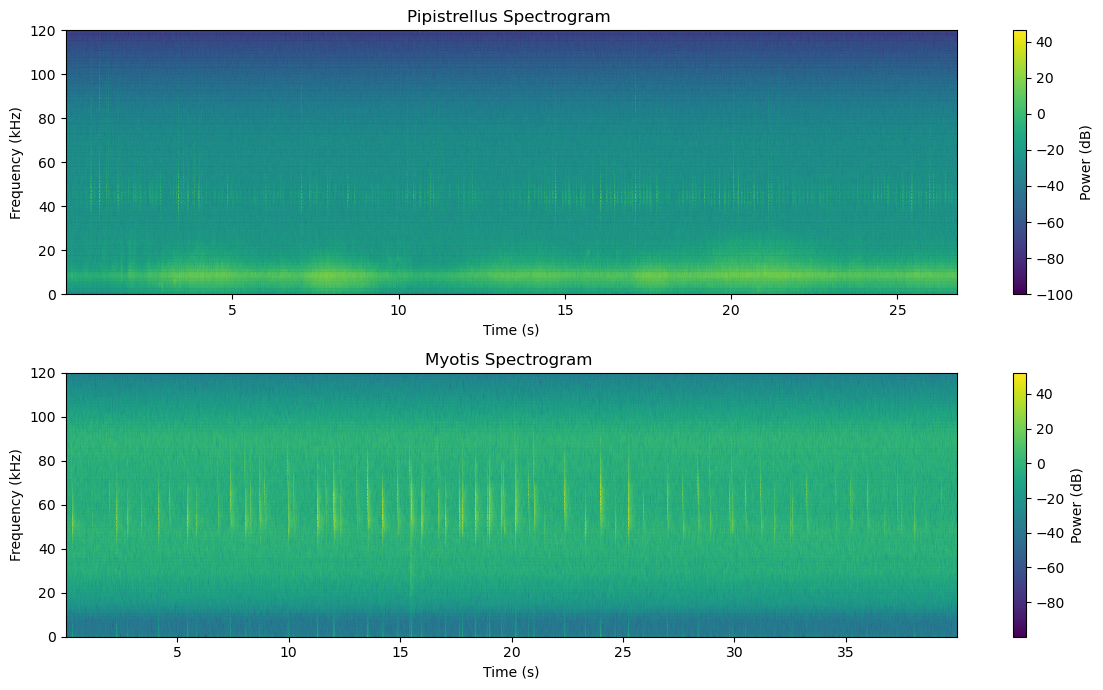

In [9]:

plt.figure(figsize=(12,7))

# Pipistrellus spectrogram
plt.subplot(2,1,1)

f, t, Sxx = spectrogram(pip_filtered, sr_pip)

plt.pcolormesh(t, f/1000,
               10*np.log10(Sxx + 1e-10),
               shading='gouraud')

plt.title("Pipistrellus Spectrogram ")
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.ylim(0,120)
plt.colorbar(label="Power (dB)")

# Myotis spectrogram
plt.subplot(2,1,2)

f, t, Sxx = spectrogram(myo_filtered, sr_myo)

plt.pcolormesh(t, (f*division_factor)/1000,
               10*np.log10(Sxx + 1e-10),
               shading='gouraud')

plt.title("Myotis Spectrogram ")
plt.ylabel("Frequency (kHz)")
plt.xlabel("Time (s)")
plt.ylim(0,120)
plt.colorbar(label="Power (dB)")

plt.tight_layout()
plt.show()